In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import holidays

In [3]:
df = pd.read_csv('../data/raw/cleaned_transactions.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


In [4]:
df.shape

(514547, 9)

In [5]:
df.isna().sum()

InvoiceNo                0
StockCode                0
Description              0
Quantity                 0
InvoiceDate              0
Price                    0
Customer ID         103815
Country                  0
transaction_type         0
dtype: int64

In [6]:
df = df[df["Quantity"] > 0]
df.shape[0]

504731

In [7]:
df["Quantity"].describe()

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

In [8]:
df = df.sort_values(by = "Quantity", ascending = False)
df["Quantity"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]) 

0.50      3.0
0.75     12.0
0.90     24.0
0.95     32.0
0.99    120.0
Name: Quantity, dtype: float64

# Filter 99th Percentile

In [9]:
df = df[df['Quantity'] < 120]
print(df.shape[0])
print(df["Quantity"].describe())

499511
count    499511.000000
mean          7.950960
std          12.571962
min           1.000000
25%           1.000000
50%           3.000000
75%          10.000000
max         119.000000
Name: Quantity, dtype: float64


In [10]:
# Convert InvoiceDate to datetime and set it as index for time-series modeling
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
print(df['InvoiceDate'].max())
print(df['InvoiceDate'].min()) 

2010-12-09 20:01:00
2009-12-01 07:45:00


# Feature Engineering

### Aggregate Data to Daily Demand

In [12]:
# Convert 'InvoiceDate' to datetime and extract day from timestamp
df['InvoiceDate'] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()

def aggregate_daily_demand(df):

    daily_demand = (
        df.groupby(
            ["InvoiceDate", "StockCode"],
            as_index=False
        )
        .agg(
            Quantity=("Quantity", "sum"),
            Price=("Price", "mean")
        )
    )

    return daily_demand

daily_demand_df = aggregate_daily_demand(df)

In [13]:
daily_demand_df.head()

,InvoiceDate,StockCode,Quantity,Price
0,2009-12-01,10002,12,0.850
1,2009-12-01,10120,60,0.210
2,2009-12-01,10123C,3,1.300
3,2009-12-01,10123G,2,1.700
4,2009-12-01,10125,5,1.275


In [14]:
daily_demand_df.shape

(264782, 4)

In [15]:
# timebased train-valid split
cutoff_date = '2010-10-01'

def train_valid_split(
    df,
    date_col,
    split_date
):

    train_df = df[
        df[date_col] < split_date
    ]

    valid_df = df[
        df[date_col] >= split_date
    ]

    return train_df, valid_df

# split the features
train_df, valid_df = train_valid_split(
    daily_demand_df,
    date_col='InvoiceDate',
    split_date=cutoff_date
)

print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")

Train shape: (195991, 4)
Valid shape: (68791, 4)


I will use the functions I have already written in features subfolder

In [16]:
from features.calendars import create_calendar_features
from features.easter_christmas import create_christmas_features
from features.holidays import create_holiday_features
from features.lag_features import create_lag_features
from features.momentum import create_momentum_features
from features.rolling import create_rolling_features
from features.sku import create_sku_features
from features.create_target import create_target
from features.product_lifecycle import create_product_lifecycle_features
from features.feature_pipeline import build_demand_features

In [17]:
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml"])

0

In [18]:
import pydantic
from config.feature_config import (DATE_COL, 
                                   TARGET_COL, 
                                   PRICE_COL, 
                                   PRODUCT_COL,
                                   DROP_COLS
)

In [19]:
print(DATE_COL)
print(PRICE_COL)

InvoiceDate
Price


In [20]:
# build features
train_features = build_demand_features(train_df)

In [21]:
train_features.columns

Index(['InvoiceDate', 'StockCode', 'Quantity', 'Price', 'price_ratio',
       'day_of_week', 'day_of_month', 'week_of_year', 'month', 'quarter',
       'is_weekend', 'days_to_christmas', 'christmas_window',
       'christmas_countdown', 'days_to_easter', 'easter_window', 'is_holiday',
       'holiday_name', 'days_to_next_holiday', 'days_since_previous_holiday',
       'first_sale_date', 'days_since_first_sale', 'lag_1', 'lag_7', 'lag_14',
       'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14',
       'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'momentum_7_28',
       'momentum_14_28', 'sku_mean_qty', 'sku_median_qty', 'sku_std_qty',
       'sku_cv', 'sku_avg_price', 'target'],
      dtype='str')

In [22]:
# Reuse feature builder on test no re-fit.
test_df = build_demand_features(valid_df)

In [23]:
train_features.head()

,InvoiceDate,StockCode,Quantity,Price,price_ratio,day_of_week,day_of_month,week_of_year,month,quarter,...,rolling_mean_28,rolling_std_28,momentum_7_28,momentum_14_28,sku_mean_qty,sku_median_qty,sku_std_qty,sku_cv,sku_avg_price,target
0,2009-12-01,10002,12,0.85,0.883752,1,1,49,12,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.564949
2711,2009-12-03,10002,6,0.85,0.883752,3,3,49,12,4,...,NaN,NaN,NaN,NaN,12.000000,12.0,NaN,NaN,0.85,1.945910
4021,2009-12-04,10002,73,0.85,0.883752,4,4,49,12,4,...,NaN,NaN,NaN,NaN,9.000000,9.0,4.242641,0.471404,0.85,4.304065
5550,2009-12-06,10002,49,0.85,0.883752,6,6,49,12,4,...,NaN,NaN,NaN,NaN,30.333333,12.0,37.072002,1.222154,0.85,3.912023
6516,2009-12-07,10002,2,0.85,0.883752,0,7,50,12,4,...,NaN,NaN,NaN,NaN,35.000000,30.5,31.675437,0.905012,0.85,1.098612


In [24]:
train_features.shape

(195991, 40)

In [25]:
train_features['StockCode'].nunique()

4060

In [26]:
train_features['InvoiceDate'].max()

Timestamp('2010-09-30 00:00:00')

## Build and Train LIGHTGBM Model

In [27]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error, 
                             mean_absolute_percentage_error)

# model parameters
params = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

In [28]:
X_train = train_features.drop(columns = DROP_COLS, errors = "ignore")
y_train = train_features[TARGET_COL]

X_test = test_df.drop(columns =DROP_COLS, errors = "ignore")
y_test = test_df[TARGET_COL]   

In [29]:
X_train.columns

Index(['Price', 'price_ratio', 'day_of_week', 'day_of_month', 'week_of_year',
       'month', 'quarter', 'is_weekend', 'days_to_christmas',
       'christmas_window', 'christmas_countdown', 'days_to_easter',
       'easter_window', 'is_holiday', 'holiday_name', 'days_to_next_holiday',
       'days_since_previous_holiday', 'days_since_first_sale', 'lag_1',
       'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
       'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28',
       'rolling_std_28', 'momentum_7_28', 'momentum_14_28', 'sku_mean_qty',
       'sku_median_qty', 'sku_std_qty', 'sku_cv', 'sku_avg_price'],
      dtype='str')

In [30]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [31]:
#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6249
[LightGBM] [Info] Number of data points in the train set: 195991, number of used features: 33
[LightGBM] [Info] Start training from score 14.358715
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[217]	valid_0's rmse: 19.5988


In [32]:
# make predictions
predictions = model.predict(X_test)

### Evaluation

In [33]:
from models.evaluate import evaluate, wmape_sklearn, weighted_mape

evaluate(y_true = y_test, y_pred = predictions)

{'MAE': 11.76037513270602,
 'RMSE': 19.598815685912374,
 'wmape_sklearn': np.float64(0.6989795049424707),
 'WMAPE': np.float64(0.6989795049424707)}

In [34]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE: 19.22%


In [35]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias: 16.01%
Alt result: 16.01%


### Feature Importance

Plot the feature importance to see what drove these predictions

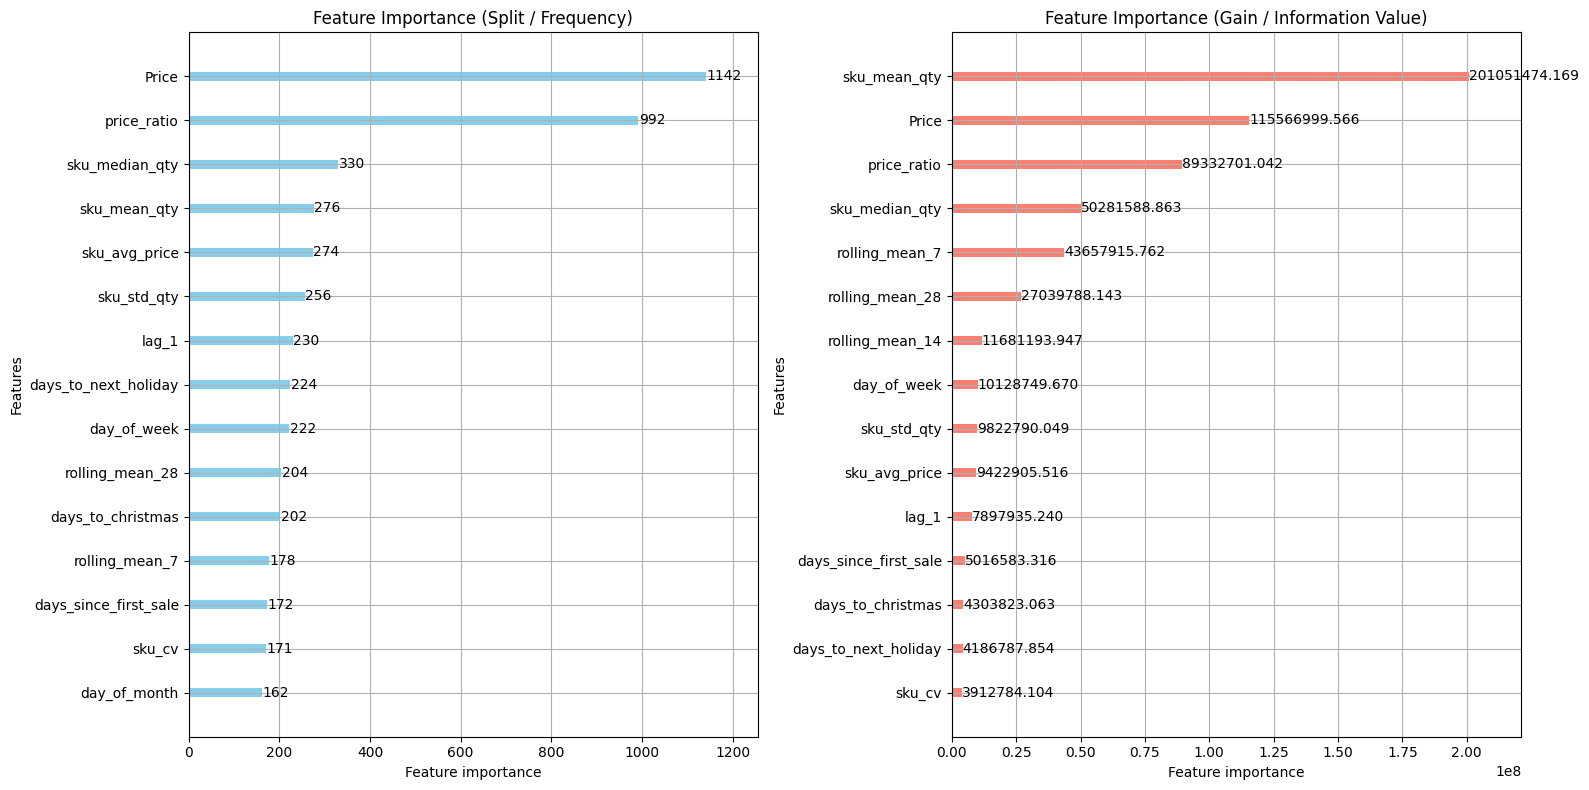

In [36]:
import matplotlib.pyplot as plt

# Configure a side-by-side plotting area
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


# Loss Function Adjustment to tweedie

By default, LightGBM optimizes for RMSE (objective: 'regression'). I want the model to focus less on penalizing these extreme outliers and instead optimize for overall percentage accuracy. Therefore, I change LightGBM objective parameter

In [37]:
# Update parameters to fix underfitting
params = {
    "objective": "tweedie",  
    "metric": "rmse",
    "tweedie_variance_power": 1.5,  # 1.5 is standard for retail sales
    "learning_rate": 0.01,
    "num_leaves": 63,
}

# Run training with more boosting rounds
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

# make predictions
tweedie_predictions = model.predict(X_test)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = tweedie_predictions)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008606 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6249
[LightGBM] [Info] Number of data points in the train set: 195991, number of used features: 33
[LightGBM] [Info] Start training from score 2.664357
Training until validation scores don't improve for 150 rounds
Did not meet early stopping. Best iteration is:
[1866]	valid_0's rmse: 19.1878


Eval metrics


{'MAE': 11.107121692449848,
 'RMSE': 19.18783166204844,
 'wmape_sklearn': np.float64(0.6601532973496216),
 'WMAPE': np.float64(0.6601532973496215)}

### Plot feature importance for tweedie

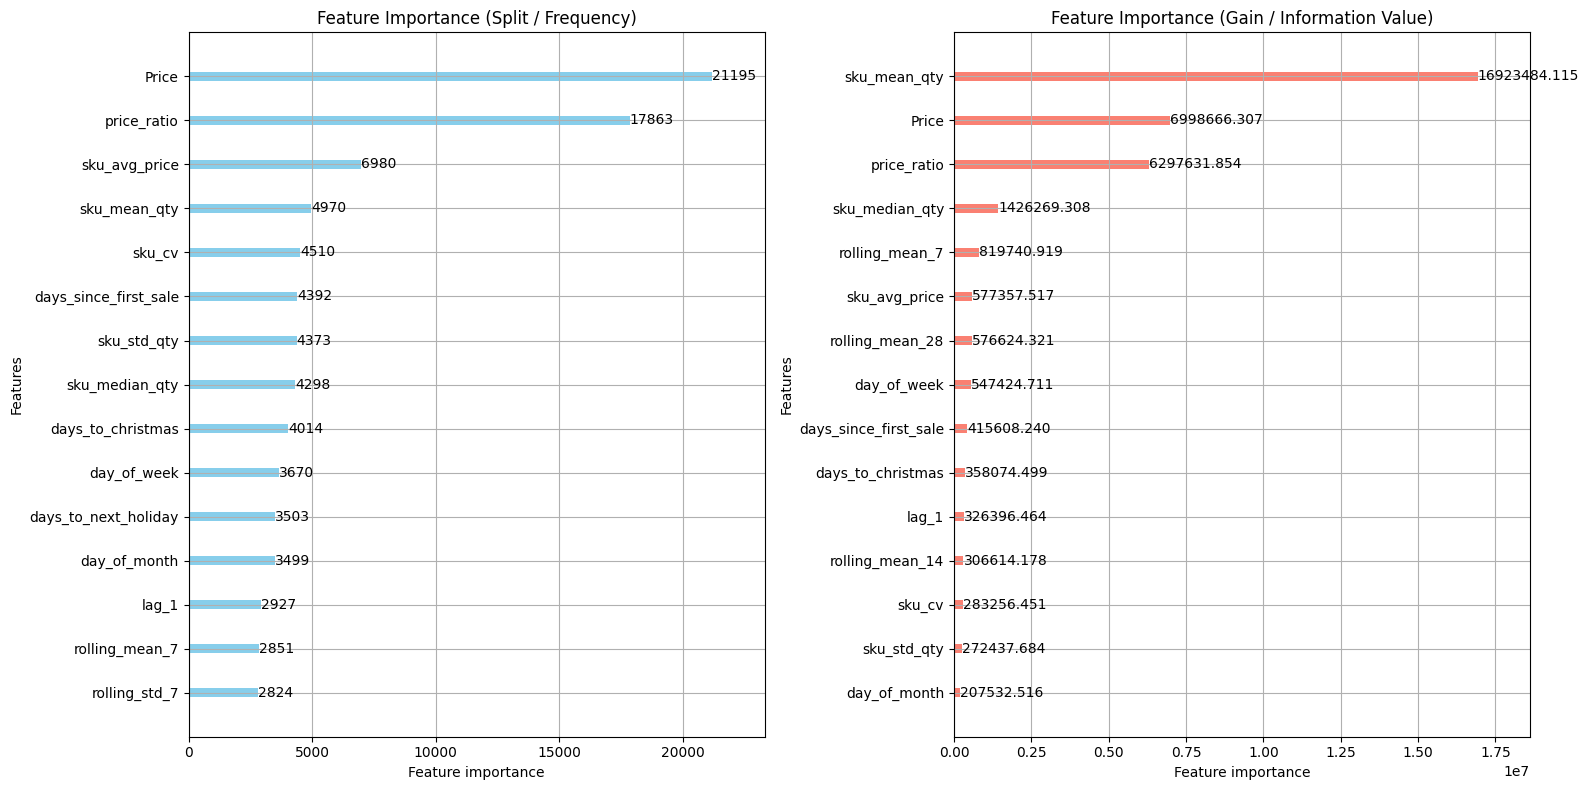

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()


In [39]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = tweedie_predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

# verify the alignment side-by-side
print(test_df[["InvoiceDate", "StockCode", "actual_demand", "predicted_demand"]].head())

       InvoiceDate StockCode  actual_demand  predicted_demand
195991  2010-10-01     11001             16         20.581402
195992  2010-10-01     16048             24         19.733874
195993  2010-10-01    16161P             25         23.237839
195994  2010-10-01     16236              6         24.321284
195995  2010-10-01     16237              5         20.859250


In [40]:
#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for tweedie: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE for tweedie: 15.96%


### Model bias

In [41]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias for tweedie: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias for tweedie: 11.62%
Alt result: 11.62%


- Aggregating data from daily to weekly dropped the **WMAPE from 66% down to 16%**. 
- For an online retailer, a 16% weekly WMAPE is a solid, operationally viable baseline. 
- Model's bias, however, is 11.6%, meaning it is over-predicting sales by 12 percent which is above the industry benchmark of plus/minus five.

# Try Objective Quantile

In [42]:
# Define your categorical features from your config
categorical_cols = ["holiday_name"]

# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)


# Define parameters for Quantile Regression
params = {
    'objective': 'quantile',
    'alpha': 0.60,              # Predicts the 58th percentile (adjust per segment)
    'metric': 'quantile',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'verbosity': -1,
    'seed': 42
}

# Train with quantile regression
q_model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[train_data, test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50), 
                  lgb.log_evaluation(100)]
                )
# make predictions
y_pred = q_model.predict(X_test)

#evaluate them
evaluate(y_true = y_test, y_pred = y_pred)

Training until validation scores don't improve for 50 rounds
[100]	training's quantile: 4.77245	valid_1's quantile: 5.59563
[200]	training's quantile: 4.58285	valid_1's quantile: 5.4497
[300]	training's quantile: 4.52537	valid_1's quantile: 5.41168
[400]	training's quantile: 4.41221	valid_1's quantile: 5.33423
[500]	training's quantile: 4.33569	valid_1's quantile: 5.29409
[600]	training's quantile: 4.28395	valid_1's quantile: 5.27479
[700]	training's quantile: 4.23184	valid_1's quantile: 5.25343
[800]	training's quantile: 4.19571	valid_1's quantile: 5.24842
[900]	training's quantile: 4.15679	valid_1's quantile: 5.23812
[1000]	training's quantile: 4.1339	valid_1's quantile: 5.23404
Did not meet early stopping. Best iteration is:
[977]	training's quantile: 4.13485	valid_1's quantile: 5.23393


{'MAE': 10.406231910104196,
 'RMSE': 19.29099432333804,
 'wmape_sklearn': np.float64(0.618495817247584),
 'WMAPE': np.float64(0.6184958172475838)}

In [43]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = y_pred

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE with quantiles: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE with quantiles: 13.59%


In [44]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100
bias_alt = (test_df['predicted_demand'].sum() - test_df['actual_demand'].sum()) / test_df['actual_demand'].sum() * 100

print(f"Model bias using quantiles: {bias_fo:.2f}%")
print(f"Alt result: {bias_alt:.2f}%")

Model bias using quantiles: -1.83%
Alt result: -1.83%


- Using quantile ojbective gives the best weekly WMAPE of **13.6%** and a bias of **-1.8%**, both operationally viable metrics. 
- It shifts the model's performance rating from poor to good.

### Why the Error Dropped So Drastically

**Day-of-Week Noise Self-Corrects:** 

Daily e-commerce sales fluctuate heavily (e.g., lower sales on Fridays, spikes on Mondays). When you pool these days into a 7-day bucket, the random daily timing variations cancel each other out. 

**Intraday Shipping and Order Latency Erasure:** 

Web traffic and processing delays frequently shift a Monday night order to a Tuesday morning fulfillment. Weekly aggregation completely erases this timing noise.

### Recommendations

**Supply Chain & Inventory (Use Weekly):** A 13.6% error rate is accurate enough to drive bulk inventory purchasing, warehouse space allocation, and vendor purchase orders. 

**Labor & Daily Ops (Do Not Use Daily):** The daily metrics proved the model is too unstable for scheduling day-to-day warehouse picking shifts or managing real-time server scaling. 

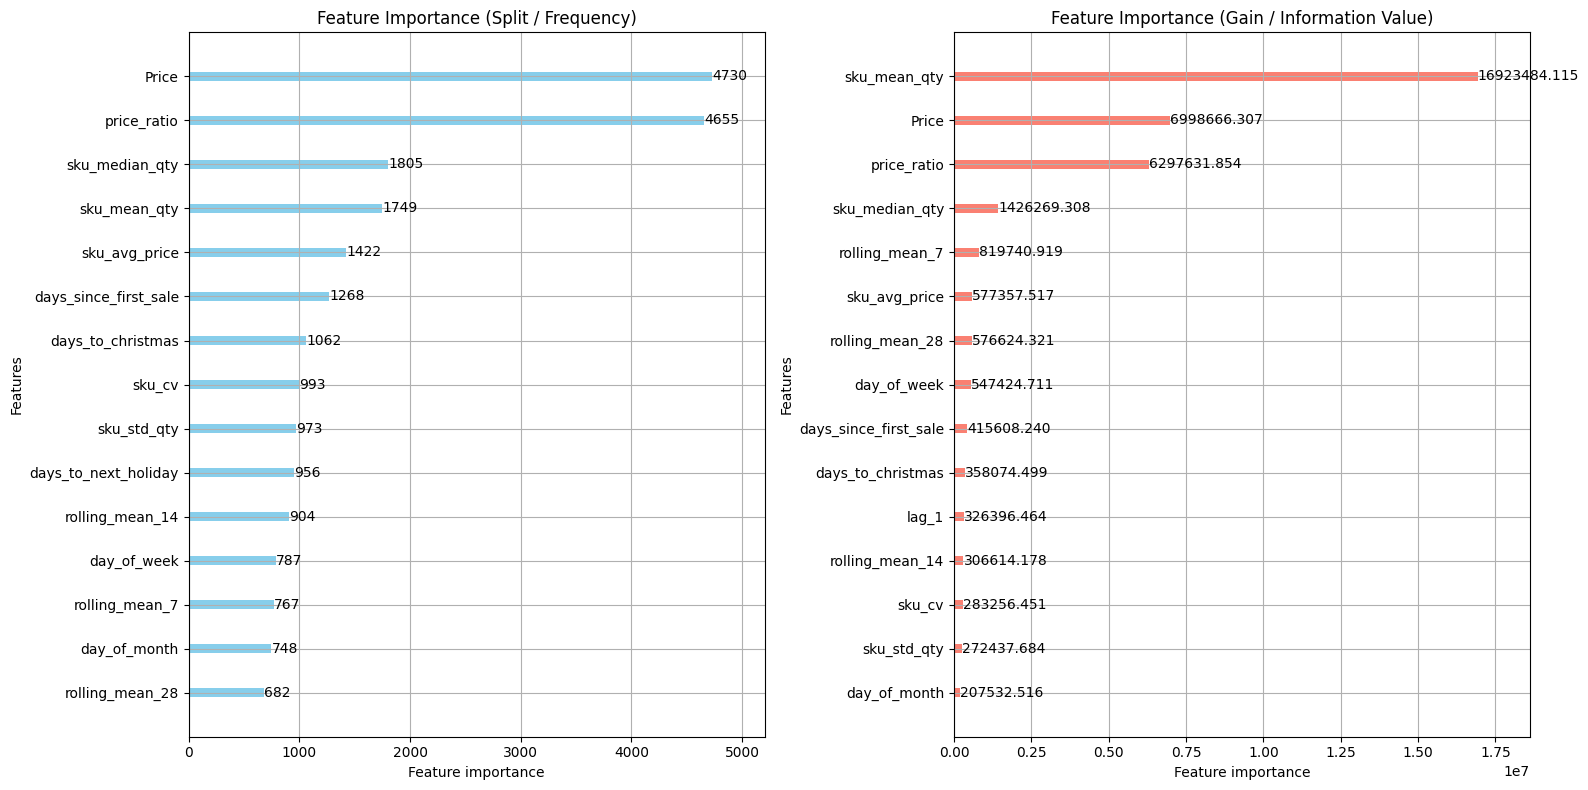

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot Split Importance (Frequency of use)
lgb.plot_importance(
    q_model, 
    importance_type="split", 
    max_num_features=15, 
    ax=ax[0], 
    title="Feature Importance (Split / Frequency)",
    color="skyblue"
)

# Plot Gain Importance (Contribution to accuracy)
lgb.plot_importance(
    model, 
    importance_type="gain", 
    max_num_features=15, 
    ax=ax[1], 
    title="Feature Importance (Gain / Information Value)",
    color="salmon"
)

plt.tight_layout()
plt.show()

### Top 10 features for split

1. Price 
2. Price ratio 
3. SKU median quantity 
4. SKU mean quantity
5. SKU avg price 
6. Days since first sale 
7. Days to christmas 
8. SKU cv
9. SKU std quantity
10. Days to next holiday

### Top 10 features for gain

1. SKU mean quantity 
2. Price 
3. Price ratio 
4. SKU median quantity 
5. Rolling mean 7 
6. SKU avg price 
7. Rolling mean 28 
8. Day of week 
9. Day since first sale
10. Days to christmas 

# Objective Huber Loss

In [46]:
# Update training parameters to huber loss function
params = {
    'objective': "huber",
    'metric': "rmse",
    #'num_leaves': 31,
    #'boosting_type': "gbdt",
    'learning_rate': 0.045,
     'n_estimators': 500,
     #'colsample_bytree': 0.8,
     #'subsample': 0.8,
     'random_state': 42,
     'verbosity': 0
}

#Train the model
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])

# make predictions
huber_pred = model.predict(X_test)
evaluate(y_true = y_test, y_pred = huber_pred)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's rmse: 24.6656


{'MAE': 11.290712868978414,
 'RMSE': 24.665601386859716,
 'wmape_sklearn': np.float64(0.671065064043599),
 'WMAPE': np.float64(0.671065064043599)}

In [47]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = huber_pred

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for huber loss: {weekly_wmape:.2%}")

## bias sum(Forecast - Actual) / sum(Actual) * 100
bias_fo = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100

print(f"Model bias for huber loss: {bias_fo:.2f}%")


Weekly Aggregated WMAPE for huber loss: 39.41%
Model bias for huber loss: -39.41%


# Log Transform Target

In [48]:
# log transform target
y_train_log = np.log1p(train_df[TARGET_COL])
y_test_log = valid_df[TARGET_COL] 

# create train data with log target
# create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=categorical_cols,)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data,
                        categorical_feature=categorical_cols,)

In [49]:
# Train model using y_train_log with regression
# model parameters
params1 = {
    'objective': "regression",
    'metric': "rmse",
    #'num_leaves': 31,
    'boosting_type': "gbdt",
    'learning_rate': 0.05,
     'n_estimators': 600,
     'colsample_bytree': 0.8,
     'subsample': 0.8,
     'random_state': 42
}

model = lgb.train(params1, train_data, num_boost_round=1000, 
                  valid_sets=[test_data], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Inverse transform predictions before evaluating
log_predictions = model.predict(X_test)
final_predictions = np.expm1(log_predictions)

# evaluate
print("\n")
print("Eval metrics")

evaluate(y_true = y_test, y_pred = final_predictions)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3]	valid_0's rmse: 30.7866


Eval metrics


{'MAE': 14.18382020584401,
 'RMSE': 28.81720582150465,
 'wmape_sklearn': np.float64(0.8430172944145394),
 'WMAPE': np.float64(0.8430172944145394)}

In [50]:
# Merge predictions directly back into test_df
test_df = valid_df.copy()
test_df["predicted_demand"] = predictions

# rename target column for clarity during aggregation
test_df = test_df.rename(columns={"Quantity": "actual_demand"})

#create weekly timestamp
test_df["week"] = test_df["InvoiceDate"].dt.to_period("W")

# aggregate weekly
weekly_df = (
    test_df.groupby(["week"])[["actual_demand", "predicted_demand"]].sum().reset_index()
)

# Calculate WMAPE on the weekly aggregation
weekly_wmape = weighted_mape(weekly_df["actual_demand"], weekly_df["predicted_demand"])
print(f"Weekly Aggregated WMAPE for log transformed target: {weekly_wmape:.2%}")

Weekly Aggregated WMAPE for log transformed target: 19.22%


In [51]:
# Formula: sum(Forecast - Actual) / sum(Actual) * 100
bias = (test_df['predicted_demand'] - test_df['actual_demand']).sum() / test_df['actual_demand'].sum() * 100

print(f"Model Bias for log transformed target: {bias:.2f}%")

Model Bias for log transformed target: 16.01%


Log transforming the target gives a weekly WMAPE that is within the industry benchmark (19.2%) but is over-forecasting by a higher rate (16%)